# Dynamic Bernoulli model in Python

This self-contained notebook translates the two MATLAB files in this chapter. It estimates a score-driven Bernoulli probability model for the annual Boat Race outcomes. Run the cells from top to bottom: each stage leaves its outputs available for the next one.


## 1. Import packages and locate the chapter folders

The notebook can be opened from the chapter folder or its `Python Notebooks` subfolder. The short path setup below finds `Data/` and `Results/` without any computer-specific path.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import LinearConstraint, minimize

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "Data"
RESULTS_DIR = PROJECT_ROOT / "Results"


c:\Users\marco\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\marco\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 2. Define the Bernoulli likelihood and probability filter

The latent state `mu_t` is the conditional probability of an outcome equal to one. For Bernoulli data, the conditional score with respect to that probability is simply the residual `y_t - mu_t`.


In [2]:
def bernoulli_logl(par, y, tsmc=0):
    """Return the negative log-likelihood, dynamic probabilities, and score residuals.

    This is the Python counterpart to ``Bernoulli_Logl.m``.  With ``tsmc=0``
    it uses the score-driven AR(1) probability recursion from the MATLAB code.
    With ``tsmc=1`` it uses the simpler two-parameter Markov specification.
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    if not np.all(np.isin(y, (0.0, 1.0))):
        raise ValueError("The Bernoulli response must contain only zeros and ones.")

    omega = par[0]  # Unconstrained mean/intercept parameter.
    if tsmc:
        kappa = par[1]  # Dynamic parameter in the simple Markov specification.
    else:
        phi = par[1]    # Dynamic AR parameter.
        kappa = par[2]  # Dynamic conditional-score parameter.

    nobs = y.size
    mu = np.empty(nobs)
    res = np.empty(nobs)

    # Start the recursion at the sample mean, as in the MATLAB implementation.
    mu_next = np.mean(y)
    for index in range(nobs):
        mu[index] = mu_next
        res[index] = y[index] - mu_next  # For Bernoulli data, the score is the residual.
        if tsmc:
            mu_next = omega + kappa * y[index]
        else:
            mu_next = omega + phi * mu_next + kappa * res[index]

    # Invalid probabilities can occur at infeasible trial values during optimization.
    if np.any(mu <= 0.0) or np.any(mu >= 1.0) or not np.all(np.isfinite(mu)):
        return np.inf, mu, res

    nll = -np.sum(y * np.log(mu) + (1.0 - y) * np.log1p(-mu))
    return nll, mu, res


## 3. Load and inspect the Boat Race outcomes

The original MATLAB code replaces a missing observation with the preceding result. The translated code applies the same rule before checking that the series is binary.


In [3]:
filename = "BoatRace46.xlsx"
outcomes = pd.to_numeric(
    pd.read_excel(DATA_DIR / filename, header=None).iloc[:, 0], errors="coerce"
).ffill().dropna()
y = outcomes.to_numpy(dtype=float)
if not np.all(np.isin(y, (0.0, 1.0))):
    raise ValueError("Boat Race outcomes must be coded as 0 or 1.")

years = np.arange(1946, 1946 + y.size)
pd.DataFrame({"year": years, "outcome": y}).head()


,year,outcome
0,1946,0.0
1,1947,1.0
2,1948,1.0
3,1949,1.0
4,1950,1.0


## 4. Choose the dynamic specification and build its constraints

With `tsmc = 0`, the notebook uses the score-driven AR(1) recursion from the MATLAB default. The constraint matrix ensures that the probability recursion remains in the unit interval. Set `tsmc = 1` to use the simpler Markov alternative.


In [4]:
tsmc = 0

if tsmc:
    start = np.array([0.1, 0.1])
    constraint_matrix = np.array([[1.0, 0.0], [1.0, 1.0]])
    bounds = [(-np.inf, np.inf), (-1.0, 1.0)]
else:
    start = np.array([0.0, 0.99, 0.1])
    constraint_matrix = np.array(
        [[1.0, 0.0, 0.0], [1.0, 0.0, 1.0],
         [1.0, 1.0, 0.0], [1.0, 1.0, -1.0]]
    )
    bounds = [(-np.inf, np.inf), (-1.0, 1.0), (-np.inf, np.inf)]

constraints = [LinearConstraint(constraint_matrix, 0.0, 1.0)]
initial_nll, initial_mu, initial_residuals = bernoulli_logl(start, y, tsmc)
print(f"Negative log-likelihood at the starting values: {initial_nll:.6f}")


Negative log-likelihood at the starting values: 56.633463


## 5. Estimate the model by constrained maximum likelihood

This cell is the Python counterpart to MATLAB's `fmincon` call. The SLSQP optimizer handles both the box bounds and the linear probability constraints. Reduce `maxiter` for a quick check.


In [5]:
maxiter = 67_000
objective = lambda par: bernoulli_logl(par, y, tsmc)[0]
optimization = minimize(
    objective, start, method="SLSQP", bounds=bounds, constraints=constraints,
    options={"maxiter": maxiter, "ftol": 1e-8, "disp": True},
)
if not optimization.success:
    print(f"Optimizer message: {optimization.message}")

par_hat = optimization.x
pd.DataFrame({"estimate": par_hat})


Optimization terminated successfully    (Exit mode 0)
            Current function value: 53.147267202369775
            Iterations: 13
            Function evaluations: 58
            Gradient evaluations: 13


,estimate
0,0.134954
1,0.741865
2,0.188650


## 6. Recover fitted probabilities and save the parameter estimates

Re-evaluating the likelihood at the optimum returns the filtered probabilities and the score residuals. Estimates are saved in the chapter `Results/` folder.


In [6]:
negative_log_likelihood, mu, residuals = bernoulli_logl(par_hat, y, tsmc)
RESULTS_DIR.mkdir(exist_ok=True)
pd.DataFrame({"estimate": par_hat}).to_excel(RESULTS_DIR / "estPar_Python.xlsx", index=False)
print(f"Fitted negative log-likelihood: {negative_log_likelihood:.6f}")


Fitted negative log-likelihood: 53.147267


C:\Users\marco\AppData\Local\Temp\ipykernel_25860\4225700204.py:3: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  pd.DataFrame({"estimate": par_hat}).to_excel(RESULTS_DIR / "estPar_Python.xlsx", index=False)


## 7. Visualize outcomes and the fitted dynamic probability

The points show the binary Boat Race outcomes; the line shows the probability implied by the fitted score-driven recursion. This mirrors the final MATLAB plot while keeping the visualization separate from estimation.


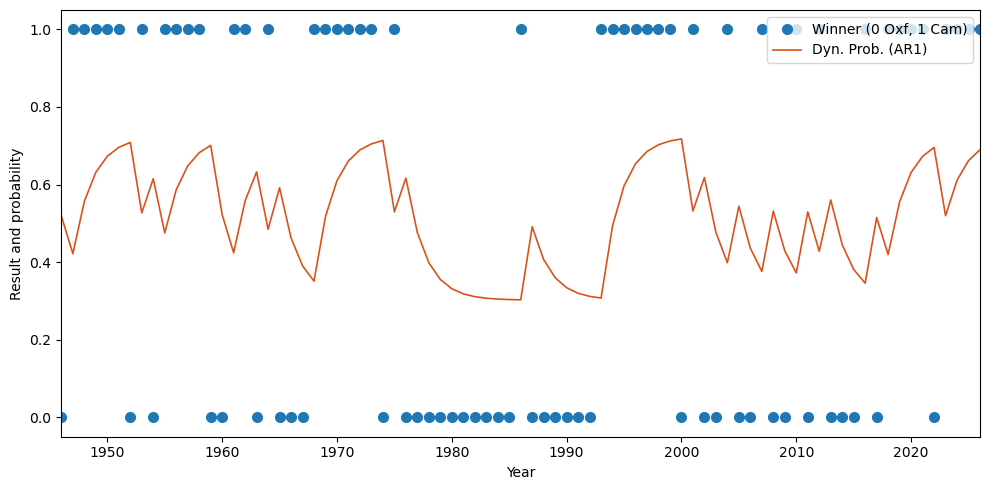

In [12]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(years, y, ".", markersize=14, label="Winner (0 Oxf, 1 Cam)")
plt.plot(years, mu, "-", linewidth=1.2, color="#d95319", label="Dyn. Prob. (AR1)")
plt.xticks(np.arange(1950, years[-1] + 1, 10))
plt.xlim(years[0], years[-1])
plt.xlabel("Year")
plt.ylabel("Result and probability")
plt.legend(loc="upper right")
plt.tight_layout()
